In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
df = pd.read_csv("Multi_Cuisine_Recipe_Dataset.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (620, 5)


,name,area,category,ingredients,steps
0,Hyderabad Soy Biryani With Vegetables & Palak,Indian,Main Course,"2 cups Basmati rice - soaked for 30 minutes,8 ...",To begin making Hyderabad Soy Biryani Recipe W...
1,Sagu Masala Dosa,Indian,South Indian Breakfast,"3/4 cup White Urad Dal (Split),1 cup Red matta...",*To Prepare the Dosa batterTo begin making the...
2,Chicken Burrito,Indian,Lunch,"300 grams Chicken - cut into stripes,1 Onion -...","To begin making the Chicken Burrito Recipe, we..."
3,Matar Paneer Kachori Korma - Green Peas And P...,Indian,Lunch,"1 cup All Purpose Flour (Maida),2 tablespoons ...",To begin making the Matar Paneer Kachori Korma...
4,Raw Jackfruit Burrito,Indian,Lunch,200 grams Jackfruit Raw (Kathal) - peeled and ...,To make the refried beansTo begin making the R...


In [3]:
df.info()

print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 620 entries, 0 to 619
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   name         620 non-null    object
 1   area         620 non-null    object
 2   category     620 non-null    object
 3   ingredients  620 non-null    object
 4   steps        620 non-null    object
dtypes: object(5)
memory usage: 24.3+ KB

Missing Values:
 name           0
area           0
category       0
ingredients    0
steps          0
dtype: int64

Duplicate Rows: 0


In [4]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Fill missing values
df.fillna("", inplace=True)

print("After cleaning:", df.shape)

After cleaning: (620, 5)


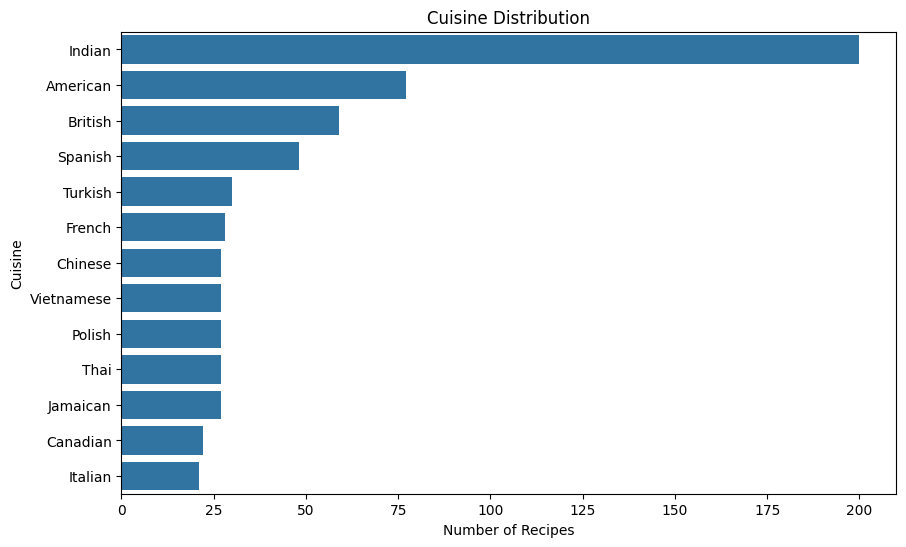

In [5]:
# Cuisine Distribution
plt.figure(figsize=(10,6))
cuisine_counts = df['area'].value_counts()

sns.barplot(x=cuisine_counts.values, y=cuisine_counts.index)
plt.title("Cuisine Distribution")
plt.xlabel("Number of Recipes")
plt.ylabel("Cuisine")
plt.show()

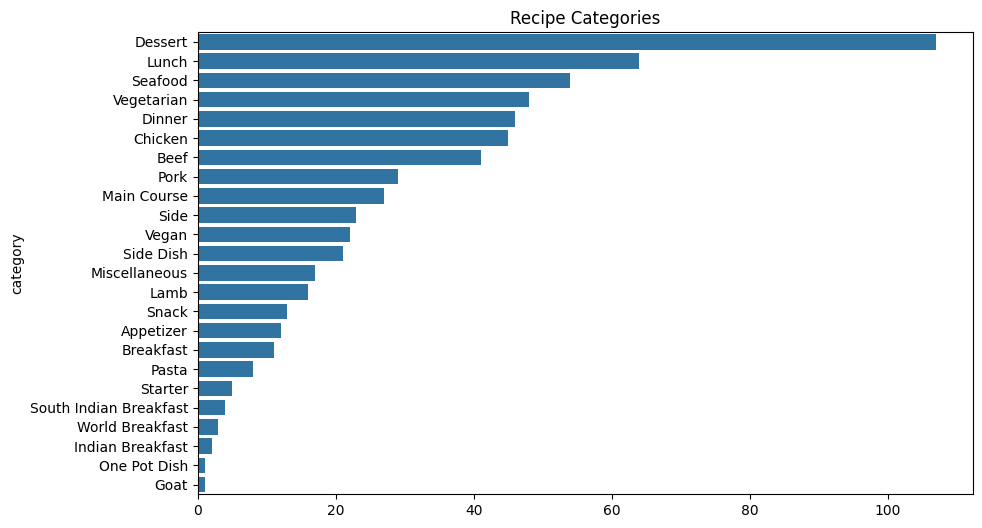

In [6]:
# Category Distribution
plt.figure(figsize=(10,6))
category_counts = df['category'].value_counts()

sns.barplot(x=category_counts.values, y=category_counts.index)
plt.title("Recipe Categories")
plt.show()

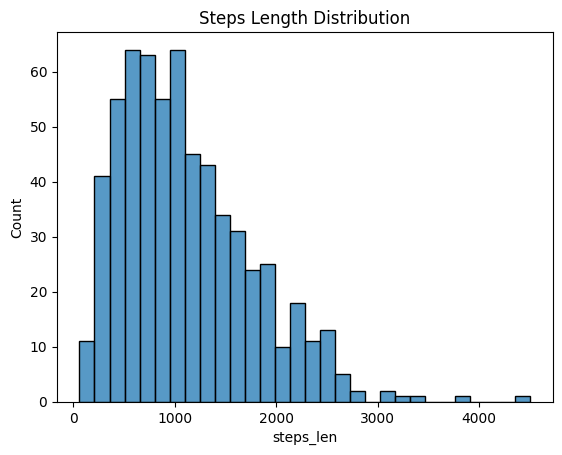

In [7]:
# Text Length Analysis
df['ingredients_len'] = df['ingredients'].apply(len)
df['steps_len'] = df['steps'].apply(len)

sns.histplot(df['steps_len'], bins=30)
plt.title("Steps Length Distribution")
plt.show()

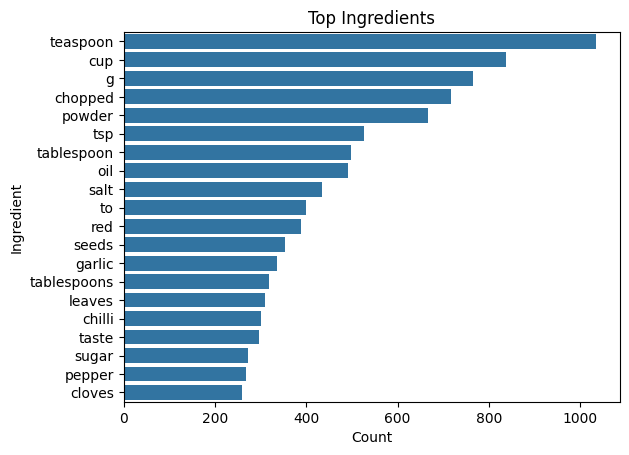

In [8]:
# Top Ingredients Analysis
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    return text

all_ingredients = " ".join(df['ingredients'])
cleaned = clean_text(all_ingredients)

words = cleaned.split()
common_words = Counter(words).most_common(20)

words_df = pd.DataFrame(common_words, columns=['Ingredient', 'Count'])

sns.barplot(data=words_df, x='Count', y='Ingredient')
plt.title("Top Ingredients")
plt.show()


In [9]:
# Prepare Data for Recommendation
df['clean_ingredients'] = df['ingredients'].apply(lambda x: x.lower())

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df['clean_ingredients'])

In [10]:
# Recommendation Function
def recommend_recipes(cuisine, user_ingredients, threshold=0.05):

    filtered_df = df[df['area'].str.lower() == cuisine.lower()]

    if filtered_df.empty:
        print("❌ No recipes found!")
        return None, None

    user_vec = vectorizer.transform([user_ingredients.lower()])
    indices = filtered_df.index

    similarity = cosine_similarity(user_vec, tfidf_matrix[indices])

    sim_scores = list(enumerate(similarity[0]))

    # NEW: Filter using threshold
    sim_scores = [(i, score) for i, score in sim_scores if score > threshold]

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    if len(sim_scores) == 0:
        print("No matching recipes!")
        return None, None

    sorted_indices = [indices[i[0]] for i in sim_scores]
    scores = [i[1] for i in sim_scores]   # ⭐ NEW

    return df.loc[sorted_indices], scores

In [11]:
'''print("🍽️ Recipe Recommendation System")

cuisine_input = input("Enter cuisine: ")
ingredients_input = input("Enter ingredients: ")

results, scores = recommend_recipes(cuisine_input, ingredients_input)

if results is not None:

    print("\n Top 3 Recommended Dishes:\n")
    top3 = results.head(3)

    # Show top 3 with match %
    for i, (idx, score) in enumerate(zip(top3.index, scores[:3]), 1):
        print(f"{i}. {df.loc[idx, 'name']}  ⭐ Match: {round(score*100,2)}%")

    choice = input("\nEnter 1/2/3 OR type 'all': ")

    # If user selects ALL
    if choice.lower() == "all":
        print("\n🍽️ All Relevant Recipes (Based on Ingredients):\n")

        for i, (idx, score) in enumerate(zip(results.index, scores), 1):
            print(f"{i}. {df.loc[idx, 'name']}  ⭐ Match: {round(score*100,2)}%")

        # Options after showing all
        print("\nOptions:")
        print("1. Enter dish number to view recipe")
        print("2. Exit")

        user_choice = input("\nEnter your choice (1 or 2): ")

        if user_choice == "1":
            try:
                dish_num = int(input("Enter dish number: "))

                if 1 <= dish_num <= len(results):
                    selected = results.iloc[dish_num - 1]

                    print("\n🍽️ Recipe Name:", selected['name'])
                    print("\n🧂 Ingredients:\n", selected['ingredients'])
                    print("\n👨‍🍳 Steps:\n", selected['steps'])
                else:
                    print("❌ Invalid dish number!")

            except ValueError:
                print("❌ Please enter a valid number!")

        elif user_choice == "2":
            print("👋 Exiting...")

        else:
            print("❌ Invalid option!")

    # If user selects from Top 3
    elif choice in ['1', '2', '3']:
      selected = top3.iloc[int(choice)-1]

        print("\n🍽️ Recipe Name:", selected['name'])
        print("\n🧂 Ingredients:\n", selected['ingredients'])
        print("\n👨‍🍳 Steps:\n", selected['steps'])

    else:
        print("❌ Invalid input")'''

'print("🍽️ Recipe Recommendation System")\n\ncuisine_input = input("Enter cuisine: ")\ningredients_input = input("Enter ingredients: ")\n\nresults, scores = recommend_recipes(cuisine_input, ingredients_input)\n\nif results is not None:\n    \n    print("\n Top 3 Recommended Dishes:\n")\n    top3 = results.head(3)\n    \n    # Show top 3 with match %\n    for i, (idx, score) in enumerate(zip(top3.index, scores[:3]), 1):\n        print(f"{i}. {df.loc[idx, \'name\']}  ⭐ Match: {round(score*100,2)}%")\n    \n    choice = input("\nEnter 1/2/3 OR type \'all\': ")\n    \n    # If user selects ALL\n    if choice.lower() == "all":\n        print("\n🍽️ All Relevant Recipes (Based on Ingredients):\n")\n        \n        for i, (idx, score) in enumerate(zip(results.index, scores), 1):\n            print(f"{i}. {df.loc[idx, \'name\']}  ⭐ Match: {round(score*100,2)}%")\n        \n        # Options after showing all\n        print("\nOptions:")\n        print("1. Enter dish number to view recipe")\n 

In [13]:
# =========================================
# 📌 Interactive Recommendation System (Kaggle Version)
# =========================================
print("🍽️ Recipe Recommendation System")

# 🔥 Simulated Inputs (replace these values to test)
cuisine_input = "Indian"
ingredients_input = "rice tomato onion"
choice = "all"          # options: "1", "2", "3", "all"
user_choice = "1"       # options: "1" or "2"
dish_num = 2            # choose dish number

print("Cuisine:", cuisine_input)
print("Ingredients:", ingredients_input)

results, scores = recommend_recipes(cuisine_input, ingredients_input)

if results is not None:

    print("\n🔥 Top 3 Recommended Dishes:\n")
    top3 = results.head(3)

    # Show top 3 with match %
    for i, (idx, score) in enumerate(zip(top3.index, scores[:3]), 1):
        print(f"{i}. {df.loc[idx, 'name']}  ⭐ Match: {round(score*100,2)}%")

    print("\nChoice:", choice)
     # =========================================
    # 📌 If user selects ALL
    # =========================================
    if choice.lower() == "all":
        print("\n🍽️ All Relevant Recipes (Based on Ingredients):\n")

        for i, (idx, score) in enumerate(zip(results.index, scores), 1):
            print(f"{i}. {df.loc[idx, 'name']}  ⭐ Match: {round(score*100,2)}%")

        print("\nOptions:")
        print("1. Enter dish number to view recipe")
        print("2. Exit")

        print("User Choice:", user_choice)

        if user_choice == "1":
            try:
                print("Selected Dish Number:", dish_num)

                if 1 <= dish_num <= len(results):
                    selected = results.iloc[dish_num - 1]

                    print("\n🍽️ Recipe Name:", selected['name'])
                    print("\n🧂 Ingredients:\n", selected['ingredients'])
                    print("\n👨‍🍳 Steps:\n", selected['steps'])

                else:
                    print("❌ Invalid dish number!")

            except ValueError:
                print("❌ Please enter a valid number!")

        elif user_choice == "2":
            print("👋 Exiting...")

        else:
            print("❌ Invalid option!")

    # =========================================
    # 📌 If user selects from Top 3
    # =========================================
    elif choice in ['1', '2', '3']:
        selected = top3.iloc[int(choice)-1]

        print("\n🍽️ Recipe Name:", selected['name'])
        print("\n🧂 Ingredients:\n", selected['ingredients'])
        print("\n👨‍🍳 Steps:\n", selected['steps'])

    else:
        print("❌ Invalid input")

🍽️ Recipe Recommendation System
Cuisine: Indian
Ingredients: rice tomato onion

🔥 Top 3 Recommended Dishes:

1. Chicken Burrito   ⭐ Match: 15.49%
2. Vegan Burger  With Beans And Tofu Patty  ⭐ Match: 15.46%
3. Raw Jackfruit Burrito   ⭐ Match: 15.1%

Choice: all

🍽️ All Relevant Recipes (Based on Ingredients):

1. Chicken Burrito   ⭐ Match: 15.49%
2. Vegan Burger  With Beans And Tofu Patty  ⭐ Match: 15.46%
3. Raw Jackfruit Burrito   ⭐ Match: 15.1%
4. Aromatic Vegetable Pulao   ⭐ Match: 14.78%
5. Mexican Style Vegetarian Chimichanga -Deep Fried Burrito  ⭐ Match: 14.52%
6. Hyderabadi Vegetable Biryani  - Hyderabadi Vegetable Biryani   ⭐ Match: 14.42%
7. Healthy Black Bean Burger  Without Bun  ⭐ Match: 13.8%
8. Homemade Spicy Ramen with Tofu   ⭐ Match: 13.37%
9. Mexican Vegetarian Burrito Bowl   ⭐ Match: 13.18%
10. Singapore Style Chicken Layered Fried Rice   ⭐ Match: 12.7%
11. Palak Kichadi   ⭐ Match: 12.68%
12. Kashmiri Style Yakhni Pulao With Chicken   ⭐ Match: 12.66%
13. Asian Style Bab